# ContinuousDPs.jl: Multidimensional-state Stochastic Optimal Growth Model with Leisure

This notebook demonstrates how to use `ContinuousDPs.jl` to solve a multidimensional-state dynamic programming problem.

We consider the stochastic optimal growth model with lesiture from Santos (1999) Section 7.3:

\begin{align*}
    \max_{\{c_t, l_t\}} \mathbb{E}_0 \sum_{t=0}^{\infty} \beta^t
    \left[ \lambda \log c_t + (1 - \lambda) \log l_t \right]
\end{align*}

subject to

\begin{align*}
c_t + k_{t+1} &= z_t A k_t^\alpha (1 - l_t)^{1-\alpha} + (1 - \delta) k_t,\\
\log z_{t+1} &= \rho \log z_t + \varepsilon_{t+1}.
\end{align*}

Here, we let $s = (k, \log{z})$ represent the two-dimensional state of capital $k$ and log productivity $\log{z}$, $x$ the leisure ($l$), and $\varepsilon$ denote the random productivity shock.

Following Santos (1999), we reduce the problem to a unindimensional maximization over leisure $x$.

In [3]:
# Import libraries
using QuantEcon
using BasisMatrices
using ContinuousDPs
using Random
using PythonPlot
const plt = PythonPlot.pyplot;

In [2]:
# For reproducible results
seed = 42
rng = MersenneTwister(seed);

## Model setup

As in Santos (1999) Sec. 7.3, we specify the structural parameters as follows:

In [2]:
# Parameter Settings 
struct Params
    beta::Float64
    lambda::Float64
    A::Float64
    alpha::Float64
    delta::Float64
    rho::Float64
    sigma_epsilon::Float64
end

# Model parameters (as in Santos, 1999, Sec. 7.3)
p = Params(0.95, 1/3, 10.0, 0.34, 1.0, 0.90, 0.008)


Params(0.95, 0.3333333333333333, 10.0, 0.34, 1.0, 0.9, 0.008)

In [3]:
# Technology and production
y(k, z, l) = z * p.A * k^p.alpha * (1 - l)^(1 - p.alpha)

# Calculate consumption and k prime based on Santos equation (7.4) ("unidimensional maximization")
function c_from_l(k, z, l)
    return z * p.A * k^p.alpha * (1 - l)^(-p.alpha) * (p.lambda / (1 - p.lambda)) * (1 - p.alpha) * l
end

function kprime_from_l(k, z, l)
    return y(k, z, l) + (1 - p.delta) * k - c_from_l(k, z, l)
end

# Reward and transition functions
function f(s, l) 
    k, logz = s
    z = exp(logz)
    if !(0 < l < 1)
        return -Inf
    end
    c = c_from_l(k, z, l)
    kp = kprime_from_l(k, z, l)
    if c <= 0 || kp < 0
        return -Inf
    end
    return p.lambda*log(c) + (1 - p.lambda)*log(l)
end

function g(s, l, e)
    k, logz = s
    z = exp(logz)
    kp = kprime_from_l(k, z, l)
    logzp = p.rho*logz + e
    return (kp, logzp)
end

g (generic function with 1 method)

## 2. Numerical Setup

In [4]:
# State domains (as in Santos, 1999, Sec. 7.3)
logz_min, logz_max = -0.32, 0.32
k_min, k_max = 0.10, 10.0

# For numerical stability
x_lb(s), x_ub(s) = 1e-10, 1 - 1e-10

# Shock discretization (Gauss-Hermite quadrature)
n_shocks = 7
shocks, weights = qnwnorm(n_shocks, 0.0, p.sigma_epsilon^2)

([-0.03000351774180594, -0.01893407528587633, -0.009235243157919746, 0.0, 0.009235243157919746, 0.01893407528587633, 0.03000351774180594], [0.0005482688559722181, 0.030757123967586456, 0.24012317860501223, 0.4571428571428571, 0.24012317860501223, 0.030757123967586456, 0.0005482688559722181])

In [5]:
# interpolation (Chebyshev polynomial)
nk, nlogz = 5, 5
basis = Basis(
    ChebParams(nk, k_min, k_max),
    ChebParams(nlogz, logz_min, logz_max)
)

2 dimensional Basis on the hypercube formed by (0.1, -0.32) × (10.0, 0.32).
Basis families are Cheb × Cheb


In [6]:
# ContinuousDP Construction
cdp = ContinuousDP(f, g, p.beta, shocks, weights, x_lb, x_ub, basis)

ContinuousDP{2, Vector{Float64}, Matrix{Float64}, typeof(f), typeof(g), typeof(x_lb), typeof(x_ub)}(Main.f, Main.g, 0.95, [-0.03000351774180594, -0.01893407528587633, -0.009235243157919746, 0.0, 0.009235243157919746, 0.01893407528587633, 0.03000351774180594], [0.0005482688559722181, 0.030757123967586456, 0.24012317860501223, 0.4571428571428571, 0.24012317860501223, 0.030757123967586456, 0.0005482688559722181], Main.x_lb, Main.x_ub, ContinuousDPs.Interp{2, Matrix{Float64}, Matrix{Float64}, LinearAlgebra.LU{Float64, Matrix{Float64}, Vector{Int64}}}(2 dimensional Basis on the hypercube formed by (0.1, -0.32) × (10.0, 0.32).
Basis families are Cheb × Cheb
, [0.34227024433899 -0.30433808521444916; 2.140463001152258 -0.30433808521444916; … ; 7.959536998847741 0.30433808521444916; 9.75772975566101 0.30433808521444916], ([0.34227024433899, 2.140463001152258, 5.05, 7.959536998847741, 9.75772975566101], [-0.30433808521444916, -0.1880912807335914, -1.959434878635765e-17, 0.18809128073359138, 0.30

## 3. Solution

In [7]:
# Solve DP by VFI
res = solve(cdp, VFI; max_iter=500, tol = sqrt(eps()))

Compute iterate 50 with error 0.016279805077919374
Compute iterate 100 with error 0.0012526509178254486
Compute iterate 150 with error 9.638519390708922e-5
Compute iterate 200 with error 7.416356361922283e-6
Compute iterate 250 with error 5.706513563907833e-7
Compute iterate 300 with error 4.390875396609317e-8
Compute iterate 322 with error 1.4205955523038938e-8
Converged in 322 steps


ContinuousDPs.CDPSolveResult{VFI, 2, Vector{Float64}, Matrix{Float64}}(ContinuousDP{2, Vector{Float64}, Matrix{Float64}, typeof(f), typeof(g), typeof(x_lb), typeof(x_ub)}(Main.f, Main.g, 0.95, [-0.03000351774180594, -0.01893407528587633, -0.009235243157919746, 0.0, 0.009235243157919746, 0.01893407528587633, 0.03000351774180594], [0.0005482688559722181, 0.030757123967586456, 0.24012317860501223, 0.4571428571428571, 0.24012317860501223, 0.030757123967586456, 0.0005482688559722181], Main.x_lb, Main.x_ub, ContinuousDPs.Interp{2, Matrix{Float64}, Matrix{Float64}, LinearAlgebra.LU{Float64, Matrix{Float64}, Vector{Int64}}}(2 dimensional Basis on the hypercube formed by (0.1, -0.32) × (10.0, 0.32).
Basis families are Cheb × Cheb
, [0.34227024433899 -0.30433808521444916; 2.140463001152258 -0.30433808521444916; … ; 7.959536998847741 0.30433808521444916; 9.75772975566101 0.30433808521444916], ([0.34227024433899, 2.140463001152258, 5.05, 7.959536998847741, 9.75772975566101], [-0.30433808521444916,

In [8]:
# Convergence
println("VFI converged: ", res.converged, " in ", res.num_iter, " iterations.")

VFI converged: true in 322 iterations.


## 4. Analytical Benchmark

In [9]:
# Analytical solution (delta = 1)
function analytical_solution(params::Params)
    @assert params.delta == 1.0 "Analytical solution is only for delta = 1"

    ab = params.alpha * params.beta

    # Optimal leisure (constant)
    l_star = ((1 - params.lambda)*(1 - ab)) / (params.lambda*(1 - params.alpha) + ((1 - params.lambda)*(1 - ab)))
    
    # Value function: V(k, z) = B + C*log(k) + D*log(z)
    C = params.lambda * params.alpha / (1 - ab)
    D = params.lambda / ((1 - ab) * (1 - params.rho * params.beta))
    
    const_term = params.lambda * (log(1 - ab) + log(params.A) + (1 - params.alpha) * log(1 - l_star)) + (1 - params.lambda) * log(l_star) + params.beta * C * (log(ab) + log(params.A) + (1-params.alpha) * log(1 - l_star))
    B = const_term / (1 - params.beta)

    # Policy function (consant fraction of production)
    policy(k, logz) = ab * exp(logz) * params.A * k^params.alpha * (1 - l_star)^(1 - params.alpha)

    # Value function
    v_star(k, logz) = B + C * log(k) + D * logz

    return B, C, D, l_star, policy, v_star
end


analytical_solution (generic function with 1 method)

In [10]:
# Calculate analytical solution
B, C, D, l_star, policy, v_star = analytical_solution(p)

# Analytical targets on interpolation nodes
S = cdp.interp.S
k_nodes = @view S[:, 1]
logz_nodes = @view S[:, 2]
v_star_on_S = v_star.(k_nodes, logz_nodes)
k_prime_star_on_S = policy.(k_nodes, logz_nodes)

25-element Vector{Float64}:
 0.7923835123449829
 1.4778234295861785
 1.9786500465112982
 2.309679794243042
 2.475303798444655
 0.8900630579550834
 1.6599992558685037
 2.2225643057727673
 2.5944011056933824
 2.780442088820594
 ⋮
 2.418142577634339
 3.2376384268362424
 3.779297945441814
 4.050306273243436
 1.4563981962468253
 2.7162344290217293
 3.636752044744886
 4.245183593344114
 4.549599948829042

In [11]:
# Policy function benchmark check
l_hat = vec(res.X)
println("Analytical l* = ", l_star)
println("l_hat range on interpolation nodes: [", minimum(l_hat), ", ", maximum(l_hat), "]" )
println("max |l_hat - l_star| = ", maximum(abs.(l_hat .- l_star)))

# Value function benchmark check
v_hat = vec(res.V)
println("max |V_hat - V_star| = ", maximum(abs.(v_hat .- v_star_on_S)))

Analytical l* = 0.6722939424031779
l_hat range on interpolation nodes: [0.6382902824039567, 0.684742027610418]
max |l_hat - l_star| = 0.03400365999922117
max |V_hat - V_star| = 0.18207578978585914


## 5. Simulation and Figures

### 5.1 Policy Function Plots

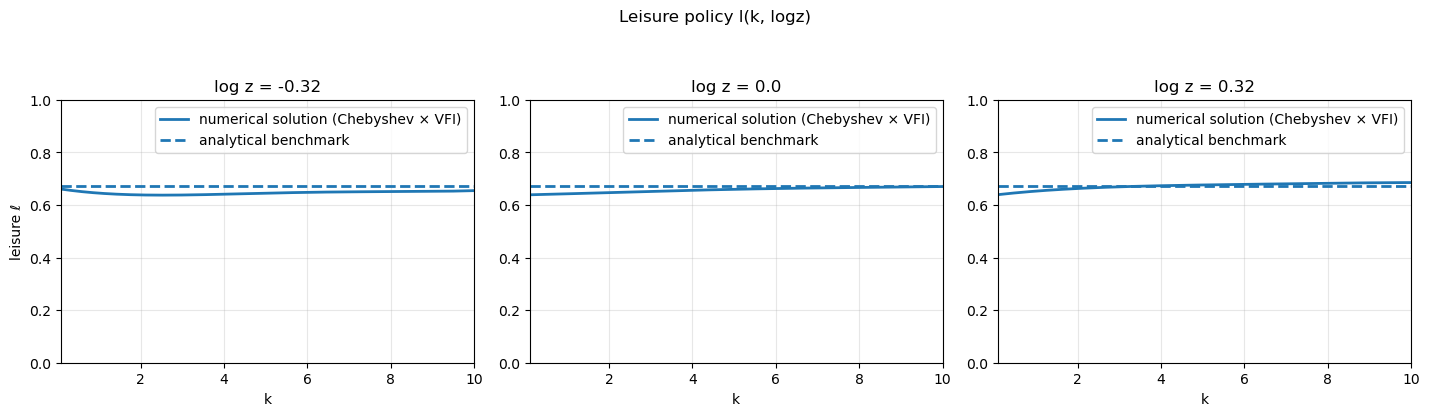

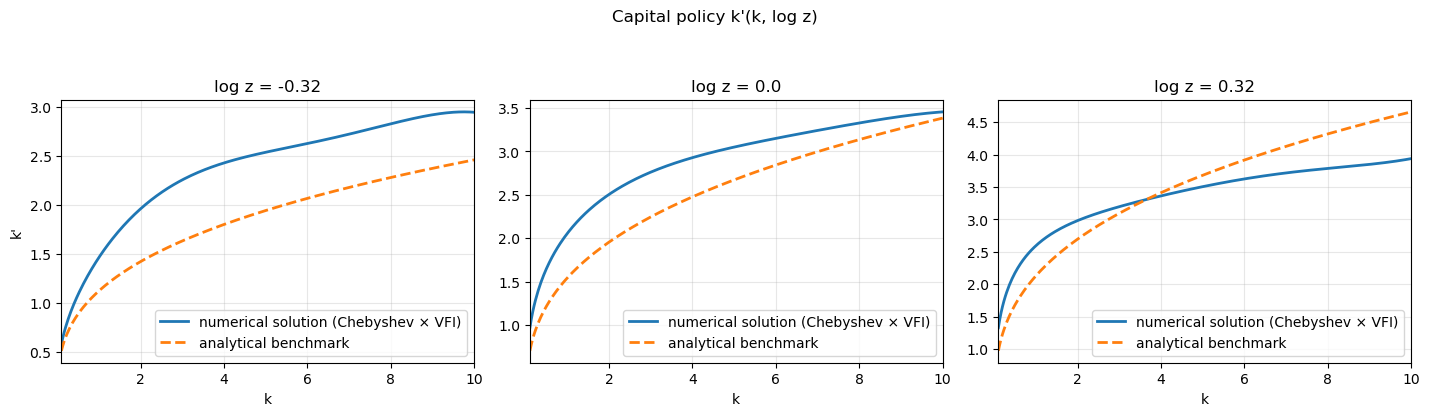

In [12]:
# Figure legend
interp_name = "Chebyshev"
method_name = "VFI"
tag = "$(interp_name) × $(method_name)"
lbl_approx = "numerical solution ($tag)"
lbl_bench  = "analytical benchmark"

# Grids
k_grid = collect(range(k_min, k_max; length=300))
logz_slices = [logz_min, 0.0, logz_max]

# Policy value on nodes
X_interp = Interpoland(basis, res.X)

# Leisure policy across k for different logz slices
ncols = length(logz_slices)
fig = plt.figure(figsize=(4.8*ncols, 4.2))

for (j, logz0) in enumerate(logz_slices)
    ax = fig.add_subplot(1, ncols, j)

    l_hat = [X_interp([k, logz0]) for k in k_grid]

    ax.plot(k_grid, l_hat, lw=2, label=lbl_approx)
    ax.axhline(l_star, lw=2, linestyle="--", label=lbl_bench)

    ax.set_title("log z = $(round(logz0, digits=2))")
    ax.set_xlabel("k")
    if j == 1
        ax.set_ylabel("leisure ℓ")
    end
    ax.set_xlim(k_min, k_max)
    ax.set_ylim(0.0, 1.0)
    ax.grid(true, alpha=0.3)
    ax.legend()
end

fig.suptitle("Leisure policy l(k, logz)")
fig.tight_layout(rect=[0, 0, 1, 0.92])
display(fig)

# Implied k' policy across k for different logz slices
fig = plt.figure(figsize=(4.8*ncols, 4.2))

for (j, logz0) in enumerate(logz_slices)
    ax = fig.add_subplot(1, ncols, j)

    z0 = exp(logz0)

    l_hat  = [X_interp([k, logz0]) for k in k_grid]
    kp_hat = [kprime_from_l(k_grid[i], z0, l_hat[i]) for i in eachindex(k_grid)]
    kp_bench = policy.(k_grid, logz0)

    ax.plot(k_grid, kp_hat,  lw=2, label=lbl_approx)
    ax.plot(k_grid, kp_bench, lw=2, linestyle="--", label=lbl_bench)

    ax.set_title("log z = $(round(logz0, digits=2))")
    ax.set_xlabel("k")
    if j == 1
        ax.set_ylabel("k'")
    end
    ax.set_xlim(k_min, k_max)
    ax.grid(true, alpha=0.3)
    ax.legend()
end

fig.suptitle("Capital policy k'(k, log z)")
fig.tight_layout(rect=[0, 0, 1, 0.92])
display(fig)


### 5.2 Value Function Plot

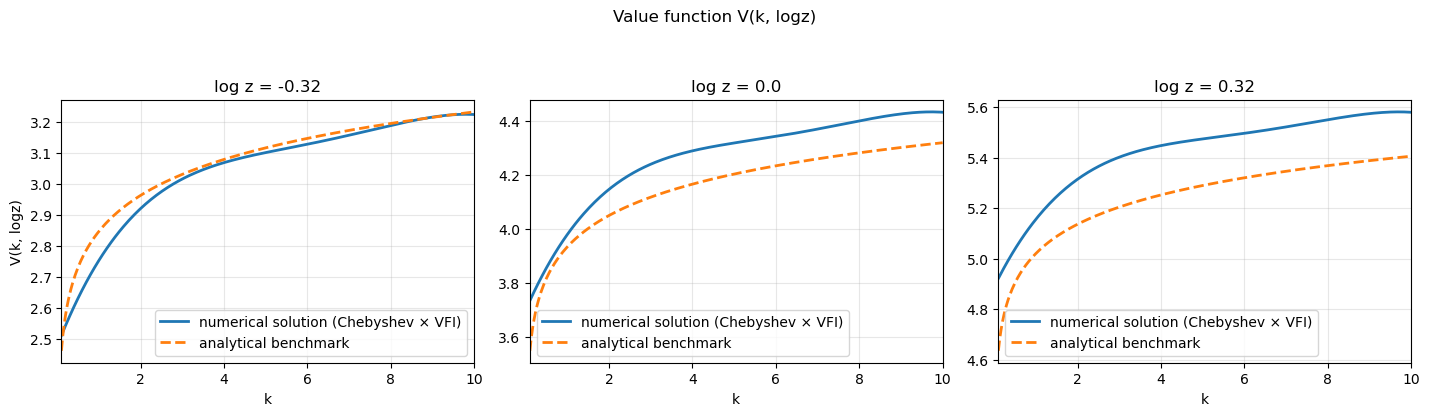

In [13]:
# Figure legend
interp_name = "Chebyshev"
method_name = "VFI"
tag = "$(interp_name) × $(method_name)"
lbl_approx = "numerical solution ($tag)"
lbl_bench  = "analytical benchmark"

k_grid = collect(range(k_min, k_max; length=300))
logz_slices = [logz_min, 0.0, logz_max]
ncols = length(logz_slices)

fig = plt.figure(figsize=(4.8*ncols, 4.2))

for (j, logz0) in enumerate(logz_slices)
    ax = fig.add_subplot(1, ncols, j)

    S_line = hcat(k_grid, fill(logz0, length(k_grid)))

    # Numerical V(k,logz)
    V_hat = vec(funeval(res.C, cdp.interp.basis, S_line))

    # Analytic benchmark
    V_bench = v_star.(k_grid, logz0)

    ax.plot(k_grid, V_hat,   lw=2, label=lbl_approx)
    ax.plot(k_grid, V_bench, lw=2, linestyle="--", label=lbl_bench)

    ax.set_title("log z = $(round(logz0, digits=2))")
    ax.set_xlabel("k")
    if j == 1
        ax.set_ylabel("V(k, logz)")
    end
    ax.set_xlim(k_min, k_max)
    ax.grid(true, alpha=0.3)
    ax.legend()
end

fig.suptitle("Value function V(k, logz)")
fig.tight_layout(rect=[0, 0, 1, 0.92])
display(fig)


### 5.3 Solutions & Errors with Multiple Methods and Interpolations

In [14]:
# For interpolation settings
struct InterpType
    type::Symbol
    label::String
    deg_k::Int
    deg_z::Int
end

interp_types = [
    InterpType(:linear, "Linear", 0, 0),
    InterpType(:spline, "Spline", 3, 1),
    InterpType(:chebyshev, "Chebyshev", 0, 0)
]

# Build interpolation basis
function build_basis(interp_type::Symbol, nk::Int, nlogz::Int;
                     kmin::Float64=k_min, kmax::Float64=k_max,
                     zmin::Float64=logz_min, zmax::Float64=logz_max,
                     deg_k::Int=3, deg_z::Int=1)
    if interp_type == :linear
        return Basis(LinParams(nk, kmin, kmax), LinParams(nlogz, zmin, zmax))

    elseif interp_type == :chebyshev
        return Basis(ChebParams(nk, kmin, kmax), ChebParams(nlogz, zmin, zmax))

    elseif interp_type == :spline
        dk = min(deg_k, nk - 1)
        dz = min(deg_z, nlogz - 1)

        @assert nk >= 2 "nk must be >= 2"
        @assert nlogz >= 2 "nlogz must be >= 2"
        @assert dk >= 1 && dz >= 1

        breaks_k = nk - (dk - 1)
        breaks_z = nlogz - (dz - 1)

        return Basis(SplineParams(breaks_k, kmin, kmax, dk), SplineParams(breaks_z, zmin, zmax, dz))
    
    else
        error("Unknown interp_type == $interp_type")
    end
end

build_basis (generic function with 1 method)

In [15]:
# Grid setup
nk, nlogz = 3, 3

# Method types
methods = [VFI, PFI]
method_names = ["VFI", "PFI"]

# Test each combination
results = Dict()

Dict{Any, Any}()

In [16]:
for (method, method_name) in zip(methods, method_names)
    for interp_type in interp_types
        simulation_name = "$(method_name) with $(interp_type.label) interpolation" 
        # Build interpolation basis
        basis = build_basis(interp_type.type, nk, nlogz)
        
        # Build DP
        cdp = ContinuousDP(f, g, p.beta, shocks, weights, x_lb, x_ub, basis)
        
        # Analytical targets on interpolation nodes
        S = cdp.interp.S
        k_nodes = @view S[:, 1]
        logz_nodes = @view S[:, 2]
        v_star_on_S = v_star.(k_nodes, logz_nodes)
        k_prime_star_on_S = policy.(k_nodes, logz_nodes)
        
        # Solve DP
        res = solve(cdp, method, max_iter=500, tol=sqrt(eps()), verbose=0)
        results[simulation_name] = res
        l_hat = vec(res.X)

        println("=== $simulation_name vs Santos(1999) analytical solution benchmark (delta = 1) ===")
        # Iteration number check
        println("Converged in $(res.num_iter) iterations")

        # Policy function benchmark check
        println("Analytical l* = ", l_star)
        println("l_hat range on interpolation nodes: [", minimum(l_hat), ", ", maximum(l_hat), "]" )
        println("max |l_hat - l_star| = ", maximum(abs.(l_hat .- l_star)))

        # Value function benchmark check
        println("max |V_hat - V_star| = ", maximum(abs.(res.V .- v_star_on_S)), "\n")
    end
end

=== VFI with Linear interpolation vs Santos(1999) analytical solution benchmark (delta = 1) ===
Converged in 314 iterations
Analytical l* = 0.6722939424031779
l_hat range on interpolation nodes: [0.4860037217238575, 0.7518796832142517]
max |l_hat - l_star| = 0.18629022067932038
max |V_hat - V_star| = 2.2915782176810966

=== VFI with Spline interpolation vs Santos(1999) analytical solution benchmark (delta = 1) ===
Converged in 322 iterations
Analytical l* = 0.6722939424031779
l_hat range on interpolation nodes: [0.512654382037513, 0.7179384904943585]
max |l_hat - l_star| = 0.15963956036566485
max |V_hat - V_star| = 1.5024207707540684

=== VFI with Chebyshev interpolation vs Santos(1999) analytical solution benchmark (delta = 1) ===
Converged in 319 iterations
Analytical l* = 0.6722939424031779
l_hat range on interpolation nodes: [0.6275505724999723, 0.7518796832142517]
max |l_hat - l_star| = 0.07958574081107384
max |V_hat - V_star| = 0.4203629692546711

=== PFI with Linear interpolatio